# 学生成绩预测：随机森林回归，并和线性回归对比

这本 notebook 用随机森林预测 `exam_score`，最后会和线性回归放在一起比较。

随机森林可以想象成：很多棵“判断树”一起做决定。每棵树都会问一些问题，比如：

- 每天学习时间是否超过 4 小时？
- 心理健康评分是否比较高？
- 娱乐时间是否比较多？

最后很多棵树的预测取平均，得到最终分数。


In [1]:
# 导入常用工具。
# pandas 用来读取和整理表格数据；numpy 用来做一些数学计算。
from pathlib import Path
import numpy as np
import pandas as pd

# matplotlib 和 seaborn 用来画图。
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import seaborn as sns

# 让图表在 notebook 里直接显示，并设置一个比较清爽的风格。
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.unicode_minus"] = False

# 中文图表标题需要中文字体。容器里通常有 Noto CJK，本机也可能有 PingFang SC。
preferred_fonts = ["Noto Sans CJK SC", "Noto Sans CJK JP", "PingFang SC", "Arial Unicode MS", "Microsoft YaHei"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        print(f"图表中文字体: {font_name}")
        break
else:
    print("没有找到常见中文字体；如果图表中文显示为方块，可以在环境中安装 Noto CJK 字体。")

DATA_FILE = "student_habits_performance.csv"
TARGET_COLUMN = "exam_score"
ID_COLUMNS = ["student_id"]


def find_data_file(filename=DATA_FILE):
    """从当前目录一路向上找 data/ml_data/filename，兼容本机和容器。"""
    search_roots = [Path.cwd(), *Path.cwd().parents, Path("/workspace")]
    for base in search_roots:
        candidate = base / "data" / "ml_data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"没有找到 {filename}，请确认它在 data/ml_data 目录下。")


data_path = find_data_file()
df = pd.read_csv(data_path)

print(f"数据文件: {data_path}")
print(f"数据大小: {df.shape[0]} 行, {df.shape[1]} 列")
df.head()


图表中文字体: Noto Sans CJK JP
数据文件: /workspace/data/ml_data/student_habits_performance.csv
数据大小: 1000 行, 16 列


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 1. 准备特征和目标

和线性回归一样，我们用学习习惯、生活习惯、家庭背景等字段预测考试分数。


In [2]:
X = df.drop(columns=[TARGET_COLUMN, *ID_COLUMNS], errors="ignore")
y = df[TARGET_COLUMN]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("数字特征:", numeric_features)
print("类别特征:", categorical_features)


数字特征: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
类别特征: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


## 2. 切分训练集和测试集

为了公平比较，随机森林和线性回归使用同一次数据切分。


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("训练集:", X_train.shape[0], "行")
print("测试集:", X_test.shape[0], "行")


训练集: 800 行
测试集: 200 行


## 3. 建立随机森林流水线

随机森林不需要像线性回归那样标准化数字，因为树模型主要看“按某个值切分”。

但文字类别仍然要做 one-hot encoding。


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# 数字列：缺失值用中位数补上。
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

# 类别列：缺失值用最常见类别补上，再做 one-hot。
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

# n_estimators=300 表示森林里有 300 棵树。
# max_depth=12 限制每棵树不要长得太复杂，减少过拟合。
forest_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

forest_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## 4. 训练并预测

和线性回归一样：先 `fit` 学规律，再 `predict` 预测测试集分数。


In [5]:
forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)

forest_comparison = pd.DataFrame({
    "真实分数": y_test.values,
    "随机森林预测分数": forest_pred,
    "误差": forest_pred - y_test.values,
})
forest_comparison.head(10)


,真实分数,随机森林预测分数,误差
0,64.2,66.163785,1.963785
1,72.7,90.082028,17.382028
2,79.0,77.713961,-1.286039
3,79.5,72.535948,-6.964052
4,58.2,54.735452,-3.464548
5,53.4,61.443397,8.043397
6,70.8,66.907248,-3.892752
7,62.5,58.918794,-3.581206
8,36.8,46.022066,9.222066
9,67.6,75.759905,8.159905


## 5. 评价随机森林

仍然用 MAE、RMSE、R² 三个指标。这样才能和线性回归公平比较。


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

forest_mae = mean_absolute_error(y_test, forest_pred)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_pred))
forest_r2 = r2_score(y_test, forest_pred)

forest_metrics = pd.DataFrame([
    {"模型": "随机森林", "MAE": forest_mae, "RMSE": forest_rmse, "R²": forest_r2}
])
forest_metrics


,模型,MAE,RMSE,R²
0,随机森林,5.026449,6.271217,0.846631


## 6. 画出真实分数和预测分数

点越靠近斜线，说明预测越准。


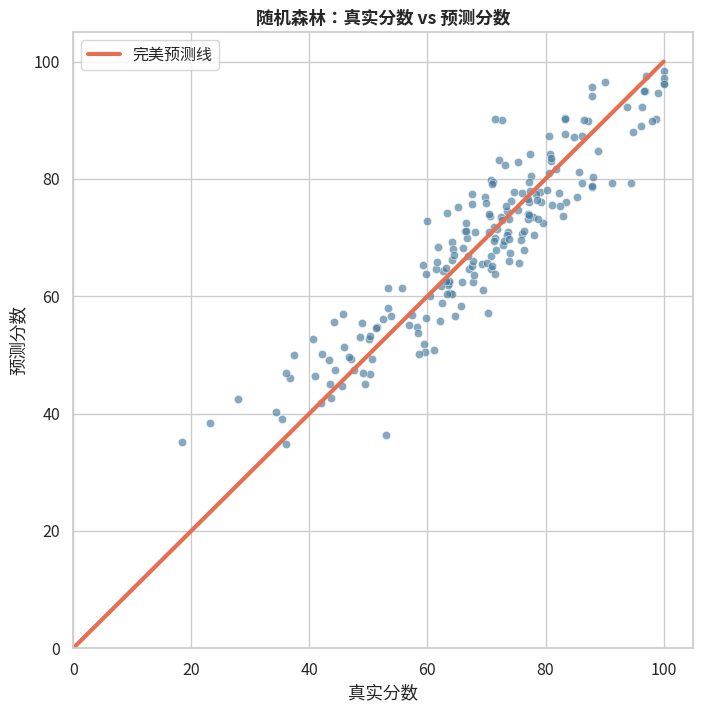

In [7]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=forest_pred, alpha=0.65, color="#457b9d")
plt.plot([0, 100], [0, 100], color="#e76f51", linewidth=3, label="完美预测线")
plt.title("随机森林：真实分数 vs 预测分数")
plt.xlabel("真实分数")
plt.ylabel("预测分数")
plt.xlim(0, 105)
plt.ylim(0, 105)
plt.legend()
plt.show()


## 7. 看随机森林认为哪些特征最重要

随机森林没有“系数”，但它能给出 feature importance，也就是每个特征对预测贡献的大致大小。


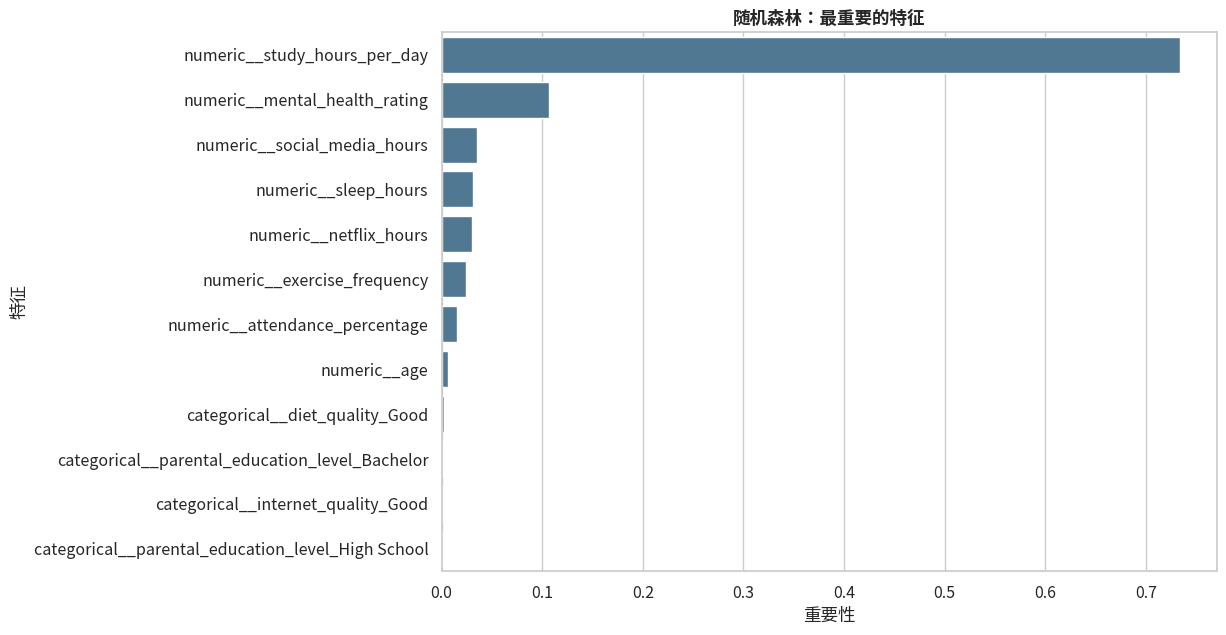

,特征,重要性
1,numeric__study_hours_per_day,0.733657
7,numeric__mental_health_rating,0.107149
2,numeric__social_media_hours,0.035243
5,numeric__sleep_hours,0.031276
3,numeric__netflix_hours,0.030271
6,numeric__exercise_frequency,0.024056
4,numeric__attendance_percentage,0.015084
0,numeric__age,0.006211
14,categorical__diet_quality_Good,0.001942
16,categorical__parental_education_level_Bachelor,0.001756


In [8]:
feature_names = forest_model.named_steps["preprocess"].get_feature_names_out()
importances = forest_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"特征": feature_names, "重要性": importances})
    .sort_values("重要性", ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, y="特征", x="重要性", color="#457b9d")
plt.title("随机森林：最重要的特征")
plt.xlabel("重要性")
plt.ylabel("特征")
plt.show()

importance_df


## 8. 和线性回归对比

现在把线性回归也在同一份训练集和测试集上跑一遍。

对比时主要看：

- MAE/RMSE 越小越好。
- R² 越大越好。


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 线性回归需要标准化数字列，所以这里重新建一个线性回归流水线。
linear_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", linear_numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocess", linear_preprocessor),
        ("model", LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

model_metrics = pd.DataFrame([
    {
        "模型": "线性回归",
        "MAE": mean_absolute_error(y_test, linear_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, linear_pred)),
        "R²": r2_score(y_test, linear_pred),
    },
    {
        "模型": "随机森林",
        "MAE": forest_mae,
        "RMSE": forest_rmse,
        "R²": forest_r2,
    },
]).sort_values("R²", ascending=False)

model_metrics


,模型,MAE,RMSE,R²
0,线性回归,4.192343,5.150974,0.896531
1,随机森林,5.026449,6.271217,0.846631


## 9. 用图表比较两个模型

左图看误差，越低越好；右图看 R²，越高越好。


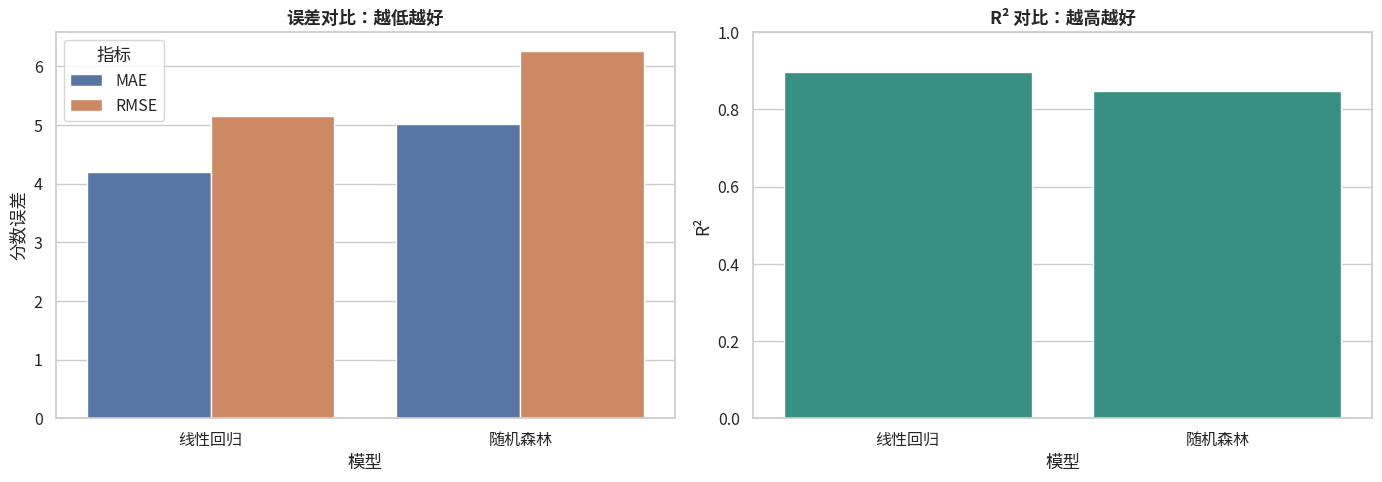

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

error_long = model_metrics.melt(
    id_vars="模型",
    value_vars=["MAE", "RMSE"],
    var_name="指标",
    value_name="误差",
)
sns.barplot(data=error_long, x="模型", y="误差", hue="指标", ax=axes[0])
axes[0].set_title("误差对比：越低越好")
axes[0].set_ylabel("分数误差")

sns.barplot(data=model_metrics, x="模型", y="R²", ax=axes[1], color="#2a9d8f")
axes[1].set_title("R² 对比：越高越好")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("R²")

plt.tight_layout()
plt.show()


## 10. 结论

在这个数据集里，线性回归通常会比随机森林表现更好。这说明成绩和这些习惯之间可能有比较明显的“线性关系”：学习时间增加，成绩整体上升；娱乐时间增加，成绩整体下降。

不过这不代表随机森林没用。随机森林适合更复杂、更弯曲的关系，只是在这份数据里，它没有超过更简单的线性回归。机器学习里经常会出现这种情况：更复杂的模型不一定更好。
